## Actividad 1
Es importante que realices todas las actividades, estas te permitirán saber como vas avanzando y podrás reflexionar sobre la teoría si te queda alguna duda de cómo hacer esta actividad por favor consultanos en el campus.

El objetivo de esta actividad es encontrar un dataset de tu interés que contenga como variable objetivo una variable continua y aplicar la regresión lineal para intentar predecirla a partir de las demás variables predictoras.

El método que seguiremos es el siguiente:

●      Preparación y organización de datos

●      Exploración de los datos

●      Modelado de datos

Ahora seguimos adelante con un poco más de teoría que nos ayudará a andar en el tema.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from google.colab import drive
drive.mount('/content/drive')
import seaborn as sns
import sklearn.metrics as sm

Mounted at /content/drive


In [3]:
from google.colab import files
uploaded = files.upload()  # te abre un explorador para elegir el archivo

Saving Salary.csv to Salary.csv


In [5]:
# Cargamos el dataset
import pandas as pd
df = pd.read_csv('Salary.csv')
print('Shape del dataset:', df.shape)
df.head()
df.corr()

Shape del dataset: (35, 2)


,YearsExperience,Salary
YearsExperience,1.000000,0.982427
Salary,0.982427,1.000000


In [ ]:
# Información general del dataset
print('Forma del dataset:', df.shape)
print('\nInformación general:')
df.info()

Forma del dataset: (35, 2)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Salary           35 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes


In [ ]:
df.describe()

,YearsExperience,Salary
count,35.000000,35.000000
mean,6.308571,83945.600000
std,3.618610,32162.673003
min,1.100000,37731.000000
25%,3.450000,57019.000000
50%,5.300000,81363.000000
75%,9.250000,113223.500000
max,13.500000,139465.000000


In [ ]:
datos_x = df['YearsExperience'].values
datos_y = df['Salary'].values
YearsExperience = []
Salary = []
for i in range(len(datos_x)):
  YearsExperience.append(datos_x[i])
for j in range(len(datos_y)):
  Salary.append(datos_y[j])
print (YearsExperience)
print (Salary)
x = np.array(YearsExperience)
y = np.array(Salary)


[np.float64(1.1), np.float64(1.3), np.float64(1.5), np.float64(2.0), np.float64(2.2), np.float64(2.9), np.float64(3.0), np.float64(3.2), np.float64(3.2), np.float64(3.7), np.float64(3.9), np.float64(4.0), np.float64(4.0), np.float64(4.1), np.float64(4.5), np.float64(4.9), np.float64(5.1), np.float64(5.3), np.float64(5.9), np.float64(6.0), np.float64(6.8), np.float64(7.1), np.float64(7.9), np.float64(8.2), np.float64(8.7), np.float64(9.0), np.float64(9.5), np.float64(9.6), np.float64(10.3), np.float64(10.5), np.float64(11.2), np.float64(11.5), np.float64(12.3), np.float64(12.9), np.float64(13.5)]
[np.int64(39343), np.int64(46205), np.int64(37731), np.int64(43525), np.int64(39891), np.int64(56642), np.int64(60150), np.int64(54445), np.int64(64445), np.int64(57189), np.int64(63218), np.int64(55794), np.int64(56957), np.int64(57081), np.int64(61111), np.int64(67938), np.int64(66029), np.int64(83088), np.int64(81363), np.int64(93940), np.int64(91738), np.int64(98273), np.int64(101302), np.i

In [ ]:
# 80% / 20%
datos_x = int(0.8 * len(x))
datos_y = len(x) - datos_x
print('Datos de entrenamiento :',(datos_x))
print('Datos de prueba :' ,(datos_y))
# Datos de entremiento
x_entrenamiento = x[:datos_x:].reshape((datos_x, 1))
y_entrenamiento = y[:datos_x:].reshape((datos_x, 1))
print(x_entrenamiento)
print(y_entrenamiento)

# Datos de prueba
x_prueba = x[datos_x:].reshape((datos_y, 1))
y_prueba = y[datos_x:].reshape((datos_y, 1))
print(x_prueba)
print(y_prueba)


Datos de entrenamiento : 28
Datos de prueba : 7
[[1.1]
 [1.3]
 [1.5]
 [2. ]
 [2.2]
 [2.9]
 [3. ]
 [3.2]
 [3.2]
 [3.7]
 [3.9]
 [4. ]
 [4. ]
 [4.1]
 [4.5]
 [4.9]
 [5.1]
 [5.3]
 [5.9]
 [6. ]
 [6.8]
 [7.1]
 [7.9]
 [8.2]
 [8.7]
 [9. ]
 [9.5]
 [9.6]]
[[ 39343]
 [ 46205]
 [ 37731]
 [ 43525]
 [ 39891]
 [ 56642]
 [ 60150]
 [ 54445]
 [ 64445]
 [ 57189]
 [ 63218]
 [ 55794]
 [ 56957]
 [ 57081]
 [ 61111]
 [ 67938]
 [ 66029]
 [ 83088]
 [ 81363]
 [ 93940]
 [ 91738]
 [ 98273]
 [101302]
 [113812]
 [109431]
 [105582]
 [116969]
 [112635]]
[[10.3]
 [10.5]
 [11.2]
 [11.5]
 [12.3]
 [12.9]
 [13.5]]
[[122391]
 [121872]
 [127345]
 [126756]
 [128765]
 [135675]
 [139465]]


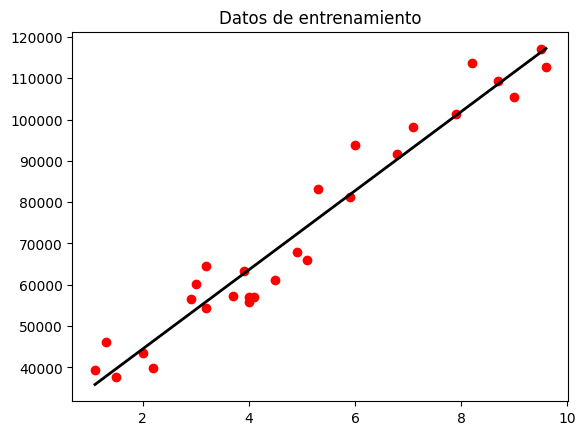

In [ ]:
linear_regressor = linear_model.LinearRegression()
linear_regressor.fit(x_entrenamiento, y_entrenamiento)
y_pred = linear_regressor.predict(x_entrenamiento)

# Gráfico
plt.figure()
plt.scatter(x_entrenamiento, y_entrenamiento, color='red')
plt.plot(x_entrenamiento, y_pred, color='black', linewidth=2)
plt.title('Datos de entrenamiento')
plt.show()

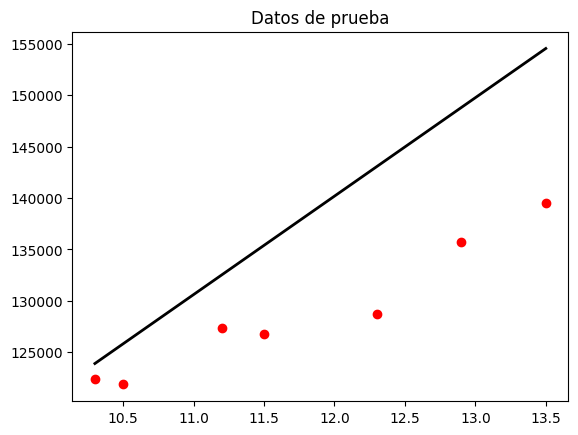

In [ ]:
y_pred_prueba = linear_regressor.predict(x_prueba)
# Gráfico
plt.figure()
plt.scatter(x_prueba, y_prueba, color='red')
plt.plot(x_prueba, y_pred_prueba, color='black', linewidth=2)
plt.title('Datos de prueba')
plt.show()


In [ ]:
print("Error absoluto medio =", round(sm.mean_absolute_error(y_prueba, y_pred_prueba), 2))
print("Error cuadrático medio =", round(sm.mean_squared_error(y_prueba, y_pred_prueba), 2))
print("Error absoluto mediano =", round(sm.median_absolute_error(y_prueba, y_pred_prueba), 2))
print("Puntuación de varianza explicada =", round(sm.explained_variance_score(y_prueba, y_pred_prueba), 2))
print("Puntuación R2 =", round(sm.r2_score(y_prueba, y_pred_prueba), 2))

Error absoluto medio = 8820.66
Error cuadrático medio = 103187712.86
Error absoluto mediano = 8636.08
Puntuación de varianza explicada = 0.31
Puntuación R2 = -1.82


En esta actividad se trabajó con un dataset que contiene dos variables: años de experiencia y salario. El objetivo fue predecir una variable continua (salario) a partir de una variable predictora (experiencia), utilizando un modelo de regresión lineal.

Primero, se realizó la carga y exploración del dataset, verificando su estructura, tipos de datos y ausencia de valores nulos. Luego, se separaron las variables en independiente (YearsExperience) y dependiente (Salary).

Posteriormente, se dividieron los datos en:

80% para entrenamiento
20% para prueba

A continuación, se entrenó un modelo de regresión lineal con los datos de entrenamiento, y se evaluó su comportamiento tanto en entrenamiento como en prueba mediante gráficos.

Finalmente, se calcularon métricas de error para evaluar el desempeño del modelo.

MAE = 8820.66
MSE = 103187712.86
R2 = -1.82

El R² es negativo (-1.82)
→ significa que el modelo predice peor que usar el promedio

Error alto
→ hay mucha diferencia entre valores reales y predichos

Si bien el modelo de regresión lineal logra ajustarse relativamente bien a los datos de entrenamiento, al evaluarlo con datos de prueba se observa un rendimiento bajo. Esto se evidencia en un valor negativo de R² y errores elevados, lo que indica que el modelo no generaliza correctamente.

Esto puede deberse a la poca cantidad de datos o a la forma en que se realizó la división del dataset. Como mejora, se podría aplicar una división aleatoria de los datos o utilizar herramientas como train_test_split para obtener resultados más representativos.